# Testing the MLIP on graphite

In [37]:
# Not relevant during the school
import jax
import numpy as np
import matplotlib.pyplot as plt
jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)


# Importing ASE modules
import ase
from ase.build import bulk, sort
from ase.optimize import BFGS
from ase.build.supercells import make_supercell
from ase.visualize import view
from ase.io.vasp import read_vasp
from ase.filters import StrainFilter # FrechetCellFilter, 


# Importing our calculator
from panna.interfaces.jax_ASE import PANNAJAXCalculator
from panna.interfaces.phonon_utils import get_phonons, plot_phonon_mode

In [38]:
# =============================================================================
# create unit cell and supercell
#uc = bulk('C','diamond', a=3.54, cubic=False) 
uc = read_vasp('div_app/POSCARS/POSCAR_graphite')
natuc = uc.get_global_number_of_atoms() 
N1, N2, N3 = 4,4,4
sc = make_supercell(uc, [[N1, 0, 0], [0, N2, 0], [0, 0, N3]])
R0 = sc.get_positions()
SCell = np.array(sc.get_cell())
natsc = sc.get_global_number_of_atoms()
masses = uc.get_masses() 
# =============================================================================

## Graphite structure
Inspect the supercell. Comment on the difference with the diamond structure

In [3]:
view(sc)

<Popen: returncode: None args: ['/home/gabriele/miniconda3/envs/tutorial/bin...>

In [40]:
# =============================================================================
# import PANNA weights
configfile = 'div_app/train_diverse/mytrain_diverse.ini' # 'dia_100_app/train_diamond_small/train.ini' #
pcalc = PANNAJAXCalculator(config=configfile) #, weights_file='epoch_930_step_93000.pkl') 
sc.calc = pcalc
# =============================================================================

INFO - reading div_app/train_diverse/mytrain_diverse.ini
INFO - Getting model div_app/train_diverse/models/epoch_1930_step_1930000.pkl


In [27]:
# =============================================================================
# relaxation
#sf = StrainFilter(sc) 
relax = BFGS(sc, trajectory='relax.traj')
relax.run(fmax=1e-09, steps=20)
Erelax = sc.get_potential_energy() #* 1/Ha_to_ev
Frelax = sc.get_forces() #/ CONV_FACT_f 
stressrelax = sc.get_stress()
SCellrelax = sc.get_cell()
# R = sc.get_positions()

# print(np.linalg.norm(R-R0, axis=1).max())
print('Max force component', abs(Frelax).max(), 'ev/A')
print('stress', stressrelax)
alat_relax = (4*SCellrelax.volume)**(1/3)
alpha, beta, gamma = SCellrelax.angles()
print('alat [A]', alat_relax/4)
print('alpha, beta, gamma [deg]', alpha, beta, gamma)
# =============================================================================

      Step     Time          Energy          fmax
BFGS:    0 21:45:59   -65094.684122        0.000809
BFGS:    1 21:46:00   -65094.684123        0.000474
BFGS:    2 21:46:01   -65094.684123        0.000003
BFGS:    3 21:46:01   -65094.684123        0.000003
BFGS:    4 21:46:02   -65094.684123        0.000003
BFGS:    5 21:46:02   -65094.684123        0.000003
BFGS:    6 21:46:03   -65094.684123        0.000003
BFGS:    7 21:46:04   -65094.684123        0.000003
BFGS:    8 21:46:04   -65094.684123        0.000003
BFGS:    9 21:46:05   -65094.684123        0.000003
BFGS:   10 21:46:06   -65094.684123        0.000003
BFGS:   11 21:46:06   -65094.684123        0.000003
BFGS:   12 21:46:07   -65094.684123        0.000003
BFGS:   13 21:46:07   -65094.684123        0.000003
BFGS:   14 21:46:08   -65094.684123        0.000003
BFGS:   15 21:46:09   -65094.684123        0.000003
BFGS:   16 21:46:09   -65094.684123        0.000003
BFGS:   17 21:46:10   -65094.684123        0.000003
BFGS:   18 21:

## Optional: seeing the cell exploding
If you run MD with this potential, what happens?

In [6]:
!ase gui relax.traj

/home/gabriele/miniconda3/envs/tutorial/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


^C


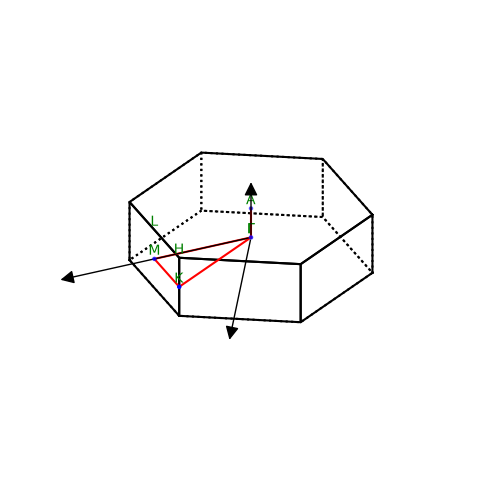

[[0.         0.         0.        ]
 [0.5        0.         0.        ]
 [0.33333333 0.33333333 0.        ]
 [0.         0.         0.        ]
 [0.         0.         0.5       ]]


In [7]:
%matplotlib widget

path = sc.cell.bandpath("GMKGA", npoints=5)
path.plot(show=True)
print(path.kpts)

In [28]:
# =============================================================================
# Phonons
kinput_scaled = np.array([
    [0.000, 0.000, 0.000],   # Γ
    [0.000, 0.500, 0.000],   # M
    [1/3, 1/3, 0.000],       # K
    [0.000, 0.000, 0.000],   # Γ
    [0.000, 0.000, 0.500]    # A
])

labels = [r'$\Gamma$', 'M', 'K', r'$\Gamma$', 'A']
interp = 10
tol = 1e-3
asr = True
dx_and_sx = True
save_freqs_eigvecs = False
connect_bands = True
verbose = True
appendix = ''
inputs_phonons = (natuc, N1, N2, N3, kinput_scaled, labels, interp, masses)
x, xcom, xlabels, kps_sc, kps, frequencies_list, eigvecs_list, Ds_list, K = get_phonons(sc, inputs_phonons, asr=asr, dx_and_sx=dx_and_sx, save_freqs_eigvecs=save_freqs_eigvecs, appendix=appendix, tol=tol, connect_bands=connect_bands, verbose=verbose)
# =============================================================================

Max initial force
[2.32150151e-06 1.16539272e-06 7.36406327e-15]
Will displace atoms of [A]  0.001
Displacing atom 0 in direction 0
Displacing atom 0 in direction -0
Displacing atom 0 in direction 1
Displacing atom 0 in direction -1
Displacing atom 0 in direction 2
Displacing atom 0 in direction -2
Displacing atom 1 in direction 0
Displacing atom 1 in direction -0
Displacing atom 1 in direction 1
Displacing atom 1 in direction -1
Displacing atom 1 in direction 2
Displacing atom 1 in direction -2
Displacing atom 2 in direction 0
Displacing atom 2 in direction -0
Displacing atom 2 in direction 1
Displacing atom 2 in direction -1
Displacing atom 2 in direction 2
Displacing atom 2 in direction -2
Displacing atom 3 in direction 0
Displacing atom 3 in direction -0
Displacing atom 3 in direction 1
Displacing atom 3 in direction -1
Displacing atom 3 in direction 2
Displacing atom 3 in direction -2
	 processing k-point: 0 [0. 0. 0.]
	 processing k-point: 1 [0.    0.023 0.   ]
	 processing k-poi

(Text(0, 0.5, 'THz'), Text(0.5, 1.0, 'Phonons in graphite'))

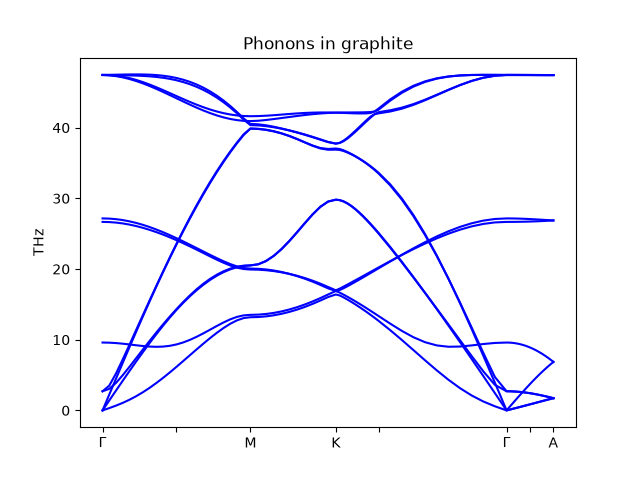

In [32]:
# =============================================================================
# band plotting
%matplotlib widget
fig,ax = plt.subplots()
for i in range(natuc*3):
   nn = ax.plot(x, frequencies_list[i], c='b', label='')#, s=1)#, marker='o', )
ax.set_xticks(xcom), ax.set_xticklabels(xlabels)
ax.set_ylabel('THz'), ax.set_title('Phonons in graphite')
# =============================================================================

# ===============================
Kpoint cartesian [0. 0. 0.] Mode 5; frequency: 9.6002 THz

Real eigenvector:
[[-0.      0.     -1.3973]
 [-0.     -0.     -1.4867]
 [ 0.     -0.      1.3973]
 [ 0.     -0.      1.4867]]
Imaginary eigenvector:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
# ===============================


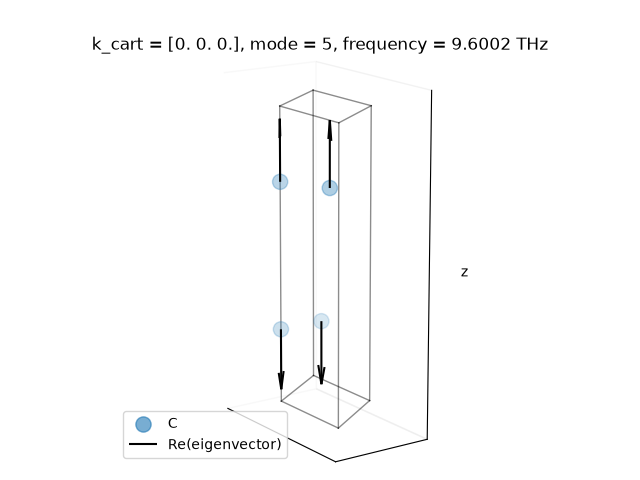

In [36]:
%matplotlib widget
ik, n = 0, 5 # second k-point, third mode
kpt = kps[ik]
omega = frequencies_list[n,ik]
eigvec = eigvecs_list[ik,:,n]
plot_phonon_mode(
    k_cart=kpt,
    n=n,
    omega=omega,
    eigvec=eigvec,
    Ruc=uc.get_positions(),
    Cell=uc.get_cell().array,
    masses=uc.get_masses(),
    symbols=uc.get_chemical_symbols(),
    ampl=10,
    repeat=(1,1,1),
    k_scale=0.5,
    #show_imag=True,
)

In [ ]:
from ase.phonons import Phonons
# =============================================================================
# import PANNA weights
configfile = 'div_app/train_yusuf/mytrain_yusuf.ini' # 
pcalc = PANNAJAXCalculator(config=configfile) #, weights_file='epoch_930_step_93000.pkl') 
uc.calc = pcalc
# =============================================================================
# =============================================================================
# relaxation
#print('Initial stress [ev/A^3]:', uc.get_stress())
#sf = StrainFilter(uc) 
relax = BFGS(uc)
relax.run(fmax=1e-09, steps=50)
# =============================================================================
# =============================================================================
# ASE phonons

# 1. finite-displacement force calculations
ph = Phonons(uc, uc.calc, supercell=(4,4,4), delta=0.001)
ph.run()

# 2. read force constants
ph.read(acoustic=True)

# 3. define path: Γ-X-W-K-Γ-L
path = sc.cell.bandpath("GMKGA", npoints=50)

# 4. phonon band structure
bs = ph.get_band_structure(path, verbose=True)

0

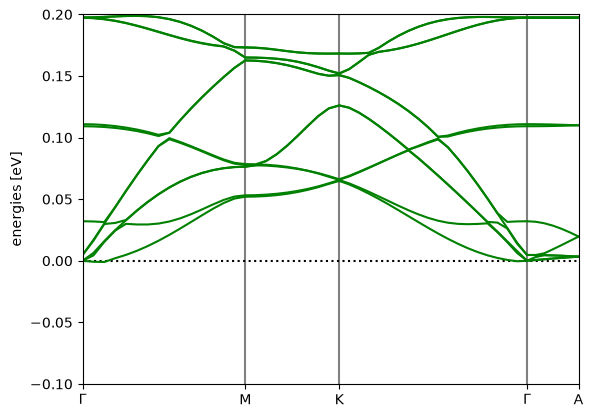

In [31]:
# 5. plot
bs.plot(emin = -0.1, emax=0.20)

# Dlist = ph.D_N
ph.clean()
# =============================================================================

INFO - reading div_app/train_yusuf/mytrain_yusuf.ini
INFO - Getting model div_app/train_yusuf/models/epoch_800_step_800000.pkl
      Step     Time          Energy          fmax
BFGS:    0 21:49:06    -1017.145485        0.000819
BFGS:    1 21:49:06    -1017.145485        0.000489
BFGS:    2 21:49:06    -1017.145485        0.000000
BFGS:    3 21:49:06    -1017.145485        0.000000
BFGS:    4 21:49:06    -1017.145485        0.000000
BFGS:    5 21:49:06    -1017.145485        0.000000
BFGS:    6 21:49:06    -1017.145485        0.000000
BFGS:    7 21:49:06    -1017.145485        0.000000
BFGS:    8 21:49:06    -1017.145485        0.000000
BFGS:    9 21:49:06    -1017.145485        0.000000
BFGS:   10 21:49:06    -1017.145485        0.000000
BFGS:   11 21:49:06    -1017.145485        0.000000
BFGS:   12 21:49:06    -1017.145485        0.000000
BFGS:   13 21:49:06    -1017.145485        0.000000
BFGS:   14 21:49:06    -1017.145485        0.000000
BFGS:   15 21:49:06    -1017.145485        

25

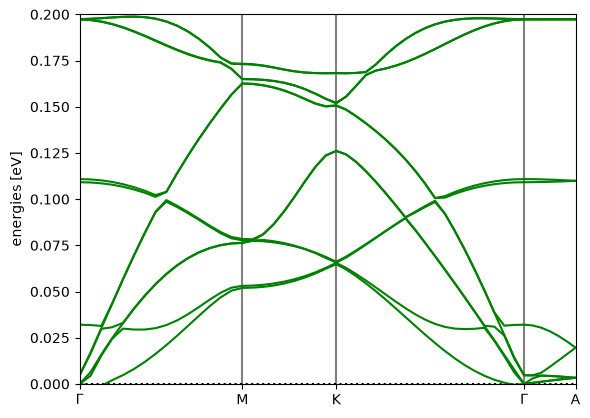

# Acoustic modes in graphite

### In-plane acoustic branches: LA and TA
- **LA (longitudinal acoustic):** atoms displaced parallel to **q**, within the basal plane.
- **TA (transverse acoustic):** atoms displaced perpendicular to **q**, but still within the basal plane.
- Both are restored by **in-plane bond stretching/bending of the strong sp² σ-bonds** — the same bonds responsible for graphite's huge in-plane stiffness.
- Near Γ, both disperse **linearly**: ω(q) ≈ v·q, exactly like an ordinary elastic (Debye) solid. The slope v is the in-plane sound velocity, directly related to the 2D elastic constants (analogous to how we extracted C₁₁, C₁₂, C₄₄ from diamond's acoustic slopes).

### Out-of-plane acoustic branch: ZA (flexural)
- Atoms displaced **perpendicular to the sheet** (the "Z" direction), all moving together at q = 0.
- The restoring force here is **bending stiffness**, not bond stretching — a much softer mechanism at long wavelength.
- Crucially, this is **not just numerically small — it's a different power law**: ω(q) ≈ α·q², quadratic rather than linear.

### Why ZA is quadratic — but only in an isolated single layer (important caveat)
For a **free-standing, isolated single sheet** (a single graphene layer with no neighboring layer to reference), rotational symmetry forbids a linear term: a rigid translation of the sheet out of plane costs zero energy (ordinary acoustic sum rule), and so does a rigid **rotation** of the sheet, since there's nothing else to tilt relative to. Together these two zero-energy constraints force the leading-order term in the flexural dispersion to be strictly quadratic, ω = αq², all the way down to q → 0. This is the textbook "flexural phonon" result and it is genuinely symmetry-protected — but **only in this isolated-membrane limit.**

**Graphite is not this limit.** Once you stack layers, each layer has a *neighbor* to bend relative to, and the (weak, van der Waals) interlayer coupling reintroduces a real restoring force at long wavelength — the rotational-invariance argument no longer applies, because rotating one layer while its neighbors stay put is no longer a zero-energy operation. Phonon calculations on graphite/multilayer graphene confirm this directly: **the ZA branch is linear at asymptotically small q, and only crosses over to the familiar q² (bending-dominated) behavior once q exceeds a small threshold** set by the ratio of interlayer coupling strength to single-layer bending stiffness. Only the true single-layer (graphene) limit pushes that threshold all the way to q = 0, i.e. purely quadratic everywhere.

# Elastic constants

In [19]:
# =============================================================================
# create unit cell and supercell
#uc = bulk('C','diamond', a=3.588, cubic=False) 
uc = read_vasp('div_app/POSCARS/POSCAR_graphite')
Cell = np.array(uc.get_cell())
# view(uc)
# =============================================================================
# =============================================================================
# import PANNA weights
configfile = 'div_app/train_diverse/mytrain_diverse.ini'
pcalc = PANNAJAXCalculator(config=configfile,
                          weights_file=-1)#'epoch_930_step_93000.pkl') 
uc.calc = pcalc
# =============================================================================
# =============================================================================
# relaxation
evA3_to_GPa = 160.21766
print('Initial stress [GPa]:', uc.get_stress()*evA3_to_GPa)
#sf = StrainFilter(uc) # StrainFilter
relax = BFGS(uc)
relax.run(fmax=1e-07, steps=20)
# Then we can collect info on the relaxed structure
Erelax = uc.get_potential_energy() 
Frelax = uc.get_forces() 
stressrelax = uc.get_stress()
Cellrelax = uc.get_cell()
# R = uc.get_positions()

# print(np.linalg.norm(R-R0, axis=1).max())
print('Max force component [ev/A]:', abs(Frelax).max())
print('relaxed stress [Gpa]:', stressrelax*evA3_to_GPa)
alat_relax = (4*Cellrelax.volume)**(1/3)
alpha, beta, gamma = Cellrelax.angles()
print('alat [A]:', alat_relax)
print('alpha, beta, gamma [deg]:', alpha, beta, gamma)
#view(sc)
# =============================================================================
# =============================================================================
# from stresses 
Cell0 = uc.get_cell().array.copy()
V0 = uc.get_volume()
stress0 = uc.get_stress()

deps = 1e-4   # try 1e-3 to 5e-3
eps = np.array([[deps, 0, 0], [0,0,0], [0,0,0]])
Celld = Cell0 @ (np.eye(3) + eps)
uc.set_cell(Celld, scale_atoms=True)
stressd = uc.get_stress()

C11 = (stressd[0] - stress0[0]) / (deps) * evA3_to_GPa
C12 = (stressd[1] - stress0[1]) / (deps) * evA3_to_GPa


print('C11 [GPa]:', C11)
print('C12 [GPa]:', C12)
# reset original undistorted cell
uc.set_cell(Cell0, scale_atoms=True)
# =============================================================================

INFO - reading div_app/train_diverse/mytrain_diverse.ini
INFO - Getting model div_app/train_diverse/models/epoch_1930_step_1930000.pkl
Initial stress [GPa]: [-2.58263193e+00 -2.58108386e+00 -1.44537160e+01  4.76329049e-17
  1.58776350e-16  2.34214487e-03]
      Step     Time          Energy          fmax
BFGS:    0 16:49:28    -1017.104439        0.000809
BFGS:    1 16:49:28    -1017.104439        0.000474
BFGS:    2 16:49:28    -1017.104439        0.000003
BFGS:    3 16:49:28    -1017.104439        0.000003
BFGS:    4 16:49:28    -1017.104439        0.000003
BFGS:    5 16:49:28    -1017.104439        0.000003
BFGS:    6 16:49:28    -1017.104439        0.000003
BFGS:    7 16:49:28    -1017.104439        0.000003
BFGS:    8 16:49:28    -1017.104439        0.000003
BFGS:    9 16:49:28    -1017.104439        0.000003
BFGS:   10 16:49:28    -1017.104439        0.000003
BFGS:   11 16:49:28    -1017.104439        0.000003
BFGS:   12 16:49:28    -1017.104439        0.000003
BFGS:   13 16:49:2